# Labwork 2 - Linear Regression

In [26]:
def read_csv(file_name):
    with open(file_name, 'r') as csv:
        data = []
        for line in csv:
            row = line.strip().split(',')
            x = float(row[0])
            y = float(row[1])
            data.append((x,y))

    for row in data:
        print(row)
        
    return data

data = read_csv('lr.csv')

(10.0, 55.0)
(20.0, 80.0)
(40.0, 100.0)
(60.0, 120.0)
(80.0, 150.0)


In [ ]:
def f(x, w0, w1):
    return w1*x + w0

# Mean square error / cost function
def loss_function(data, w0, w1):
    n = len(data)
    loss = 0
    for x, y in data:
        y_pred = f(x, w0, w1)
        loss += (1/2) * (y_pred - y) ** 2
    return loss / n

# Partial derivatives
def d_w0(data, w0, w1):
    n = len(data)
    gradient = 0
    for x, y in data:
        y_pred = f(x, w0, w1)
        gradient += y_pred - y
    return gradient / n

def d_w1(data, w0, w1):
    n = len(data)
    gradient = 0
    for x, y in data:
        y_pred = f(x, w0, w1)
        gradient += (y_pred - y) * x
    return gradient / n


def gradient_descent(data, w0, w1, learning_rate, threshold):
    i = 0
    while True:
        i += 1
        old_loss = loss_function(data, w0, w1)
        w0 = w0 - learning_rate * d_w0(data, w0, w1)
        w1 = w1 - learning_rate * d_w1(data, w0, w1)
        new_loss = loss_function(data, w0, w1)
        print(f"Iteration {i}: w1 = {w1:.4f}, w0 = {w0:.4f}, loss = {new_loss:.4f}")
        if abs(old_loss - new_loss) <= threshold:
            break
    
    return w0, w1

w0, w1 = gradient_descent(data, w0=0, w1=1, learning_rate=0.0008, threshold=0.000001)

Iteration 1: w1 = 3.1184, w0 = 0.0472, loss = 1590.2092
Iteration 2: w1 = 1.1364, w0 = 0.0232, loss = 1432.3510
Iteration 3: w1 = 2.9901, w0 = 0.0658, loss = 1292.6284
Iteration 4: w1 = 1.2557, w0 = 0.0461, loss = 1171.8104
Iteration 5: w1 = 2.8778, w0 = 0.0846, loss = 1064.6973
Iteration 6: w1 = 1.3600, w0 = 0.0687, loss = 972.2314
Iteration 7: w1 = 2.7795, w0 = 0.1037, loss = 890.1002
Iteration 8: w1 = 1.4513, w0 = 0.0910, loss = 819.3346
Iteration 9: w1 = 2.6934, w0 = 0.1230, loss = 756.3432
Iteration 10: w1 = 1.5311, w0 = 0.1132, loss = 702.1858
Iteration 11: w1 = 2.6181, w0 = 0.1425, loss = 653.8593
Iteration 12: w1 = 1.6009, w0 = 0.1352, loss = 612.4117
Iteration 13: w1 = 2.5521, w0 = 0.1621, loss = 575.3224
Iteration 14: w1 = 1.6620, w0 = 0.1570, loss = 543.6006
Iteration 15: w1 = 2.4943, w0 = 0.1818, loss = 515.1226
Iteration 16: w1 = 1.7154, w0 = 0.1787, loss = 490.8423
Iteration 17: w1 = 2.4436, w0 = 0.2017, loss = 468.9643
Iteration 18: w1 = 1.7620, w0 = 0.2002, loss = 450.3

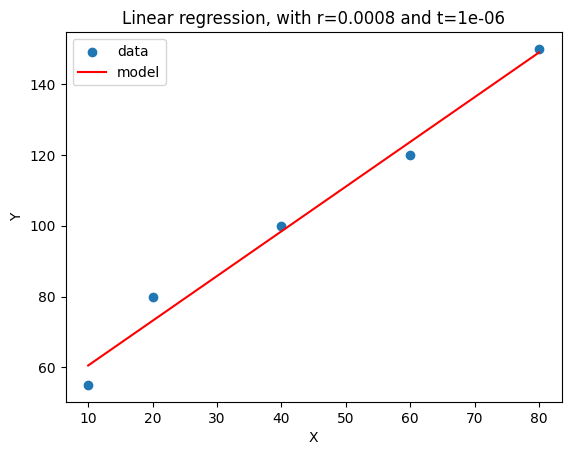

In [52]:
import matplotlib.pyplot as plt

# Data
x_vals = [x for x, y in data]
y_vals = [y for x, y in data]

# Prediction
y_pred = [w1*x + w0 for x in x_vals]

plt.scatter(x_vals, y_vals, label="data")
plt.plot(x_vals, y_pred, color="red", label="model")

plt.ylabel("Y")
plt.xlabel("X")
plt.title(f"Linear regression, with r={0.0008} and t={0.000001}")
plt.legend()
plt.show()
